In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_PATH = Path("../data/raw/tehran_house_prices.csv")
FIGURES_PATH = Path("../figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print("Raw dataset:", df_raw.shape)
print("Working dataset:", df.shape)
print("Raw data preserved:", df_raw.equals(pd.read_csv(DATA_PATH)))

Raw dataset: (3479, 8)
Working dataset: (3479, 8)
Raw data preserved: True


In [77]:
area_numeric = pd.to_numeric(df["Area"], errors="coerce")
invalid_area_mask = area_numeric.isna() & df["Area"].notna()

print("Invalid Area values:", invalid_area_mask.sum())

display(
    df.loc[
        invalid_area_mask,
        ["Area", "Room", "Address", "Price", "Price(USD)"]
    ]
)

Invalid Area values: 6


,Area,Room,Address,Price,Price(USD)
570,"3,310,000,000",2,Ostad Moein,3.310000e+09,110333.33
709,"16,160,000,000",3,Pasdaran,1.616000e+10,538666.67
807,"1,000",2,Damavand,7.000000e+09,233333.33
1604,"8,400,000,000",2,Gheitarieh,8.700000e+09,290000.00
2171,"3,600",2,Shahryar,9.720000e+09,324000.00
2802,"2,550,000,000",2,Central Janatabad,2.550000e+09,85000.00


In [78]:
room_numeric = pd.to_numeric(df["Room"], errors="coerce")
invalid_room_mask = room_numeric.isna() | (room_numeric <= 0)

print("Invalid Room records:", invalid_room_mask.sum())

display(
    df.loc[
        invalid_room_mask,
        ["Area", "Room", "Address", "Price", "Price(USD)"]
    ]
)

Invalid Room records: 10


,Area,Room,Address,Price,Price(USD)
103,40,0,Shahrake Qods,2.480000e+08,8266.67
137,40,0,Pakdasht,1.650000e+08,5500.00
1169,40,0,Ostad Moein,6.500000e+08,21666.67
2084,40,0,Pakdasht,1.650000e+08,5500.00
2103,43,0,Nasim Shahr,3.600000e+08,12000.00
2625,50,0,Northern Chitgar,3.450000e+08,11500.00
2721,110,0,Parand,1.020000e+08,3400.00
3107,630,0,Tajrish,7.560000e+10,2520000.00
3211,30,0,Ostad Moein,5.000000e+08,16666.67
3435,54,0,Shahrake Qods,4.700000e+08,15666.67


In [79]:
duplicate_mask = df.duplicated(keep=False)

print("Rows belonging to duplicate groups:", duplicate_mask.sum())
print("Duplicate rows after the first occurrence:", df.duplicated().sum())

display(
    df.loc[duplicate_mask]
      .sort_values(["Address", "Area"])
      .head(30)
)

Rows belonging to duplicate groups: 369
Duplicate rows after the first occurrence: 208


,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
72,74,2,True,True,True,Amirieh,1.700000e+09,56666.67
78,74,2,True,True,True,Amirieh,1.700000e+09,56666.67
3160,74,2,True,True,True,Amirieh,1.700000e+09,56666.67
1561,134,3,True,True,True,Andisheh,1.100000e+09,36666.67
1562,134,3,True,True,True,Andisheh,1.100000e+09,36666.67
806,216,4,True,True,False,Andisheh,5.700000e+09,190000.00
2580,216,4,True,True,False,Andisheh,5.700000e+09,190000.00
1514,95,2,True,True,True,Andisheh,1.200000e+09,40000.00
2446,95,2,True,True,True,Andisheh,1.200000e+09,40000.00
66,122,2,True,True,True,Aqdasieh,7.000000e+09,233333.33


In [80]:
missing_address_mask = df["Address"].isna()

print("Missing addresses:", missing_address_mask.sum())

display(
    df.loc[
        missing_address_mask,
        ["Area", "Room", "Parking", "Warehouse",
         "Elevator", "Price", "Price(USD)"]
    ]
)

Missing addresses: 23


,Area,Room,Parking,Warehouse,Elevator,Price,Price(USD)
43,60,2,True,True,True,2.650000e+09,88333.33
662,85,2,True,True,True,1.955000e+09,65166.67
706,117,2,True,True,True,6.500000e+09,216666.67
1108,77,2,True,True,False,2.020000e+09,67333.33
1109,71,1,True,True,True,2.300000e+09,76666.67
1577,100,2,True,True,True,3.100000e+09,103333.33
1796,70,2,True,True,True,4.830000e+09,161000.00
2071,94,2,True,True,True,3.000000e+09,100000.00
2072,99,2,True,True,True,4.150000e+09,138333.33
2127,63,1,True,True,False,7.300000e+08,24333.33


In [81]:
area_cleaned = (
    df["Area"]
    .astype("string")
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Area_numeric"] = pd.to_numeric(area_cleaned, errors="coerce")

invalid_area_mask = df["Area_numeric"].isna()

print("Area values that remain non-numeric:")
display(df.loc[invalid_area_mask, ["Area", "Room", "Address", "Price"]])

print("\nLargest parsed area values:")
display(
    df.loc[df["Area_numeric"].notna(), ["Area", "Area_numeric", "Room", "Address", "Price"]]
      .sort_values("Area_numeric", ascending=False)
      .head(15)
)

print("\nArea summary:")
display(df["Area_numeric"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

Area values that remain non-numeric:


,Area,Room,Address,Price



Largest parsed area values:


,Area,Area_numeric,Room,Address,Price
709,"16,160,000,000",16160000000,3,Pasdaran,1.616000e+10
1604,"8,400,000,000",8400000000,2,Gheitarieh,8.700000e+09
570,"3,310,000,000",3310000000,2,Ostad Moein,3.310000e+09
2802,"2,550,000,000",2550000000,2,Central Janatabad,2.550000e+09
2171,"3,600",3600,2,Shahryar,9.720000e+09
807,"1,000",1000,2,Damavand,7.000000e+09
1694,929,929,5,Zafar,8.000000e+10
1974,900,900,3,Damavand,8.500000e+09
573,863,863,2,Gheitarieh,7.830000e+09
3115,750,750,5,Varamin - Beheshti,3.500000e+09



Area summary:


count              3479.0
mean       8743999.835585
std      316726628.816516
min                  30.0
50%                  90.0
90%                 170.0
95%                 210.0
99%                 407.2
max         16160000000.0
Name: Area_numeric, dtype: Float64

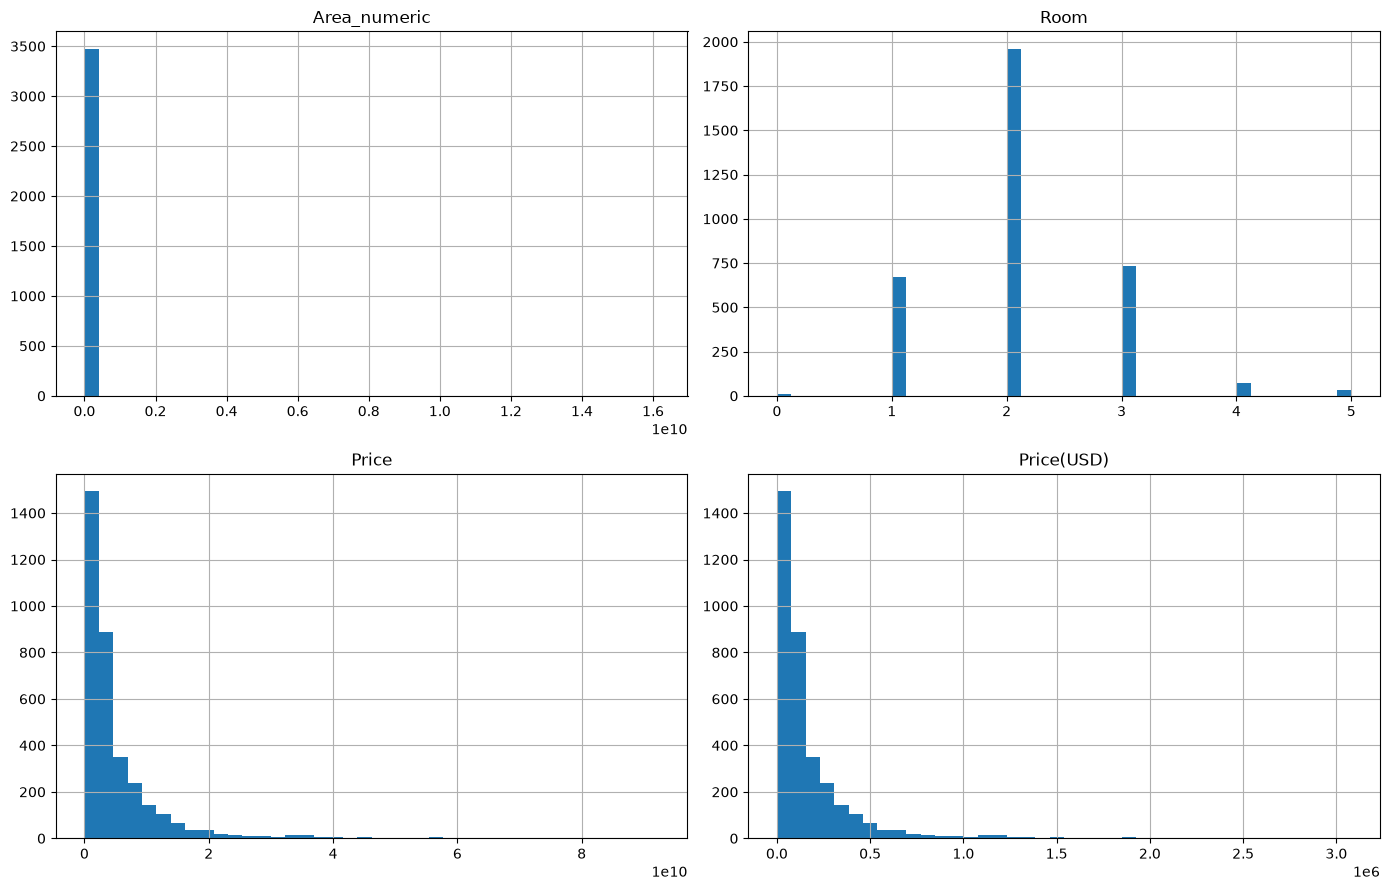

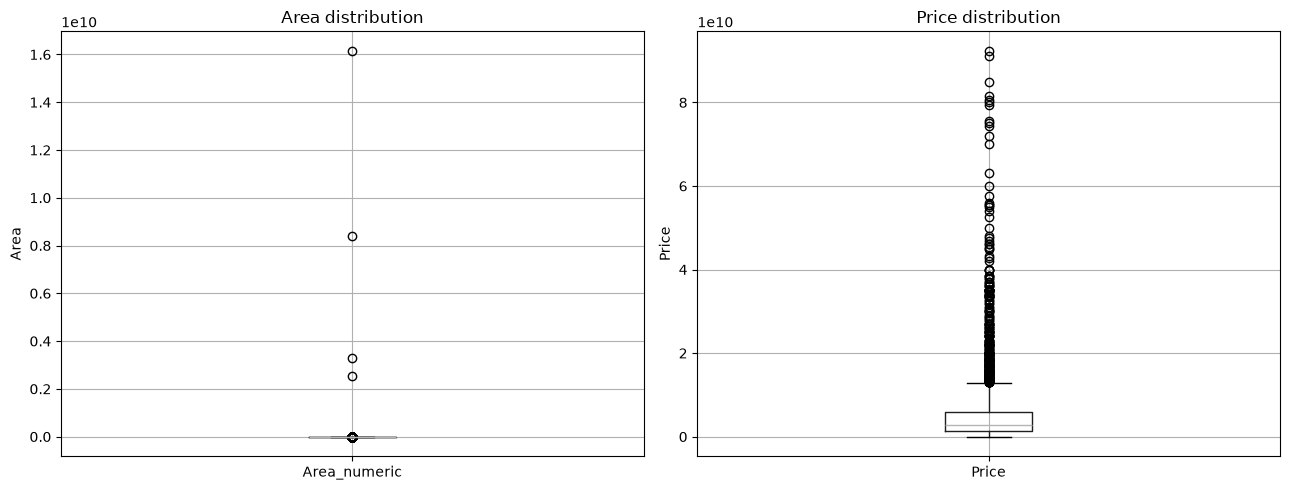

In [82]:
numeric_cols = ["Area_numeric", "Room", "Price", "Price(USD)"]

df[numeric_cols].hist(bins=40, figsize=(14, 9))
plt.tight_layout()
plt.savefig(FIGURES_PATH / "raw_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df.boxplot(column="Area_numeric", ax=axes[0])
axes[0].set_title("Area distribution")
axes[0].set_ylabel("Area")

df.boxplot(column="Price", ax=axes[1])
axes[1].set_title("Price distribution")
axes[1].set_ylabel("Price")

plt.tight_layout()
plt.savefig(FIGURES_PATH / "raw_area_price_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [83]:
price_check = df[["Price", "Price(USD)"]].copy()

price_check["implied_usd_rate"] = (
    price_check["Price"] / price_check["Price(USD)"]
)

display(price_check["implied_usd_rate"].describe())

print("First 10 price pairs:")
display(price_check.head(10))

count     3479.000000
mean     29999.999945
std          0.002406
min      29999.972727
25%      29999.999538
50%      30000.000000
75%      30000.000395
max      30000.054546
Name: implied_usd_rate, dtype: float64

First 10 price pairs:


,Price,Price(USD),implied_usd_rate
0,1.850000e+09,61666.67,29999.998378
1,1.850000e+09,61666.67,29999.998378
2,5.500000e+08,18333.33,30000.005455
3,9.025000e+08,30083.33,30000.003324
4,7.000000e+09,233333.33,30000.000429
5,2.050000e+09,68333.33,30000.001463
6,6.000000e+08,20000.00,30000.000000
7,2.150000e+09,71666.67,29999.998605
8,4.930000e+08,16433.33,30000.006085
9,2.370000e+09,79000.00,30000.000000


In [84]:
clean_df = df_raw.copy()
initial_rows = len(clean_df)
cleaning_log = []

def apply_filter(data, mask, reason):
    before = len(data)
    data = data.loc[mask].copy()
    cleaning_log.append({
        "rule": reason,
        "rows_removed": before - len(data),
        "rows_remaining": len(data)
    })
    return data

clean_df["Area"] = (
    clean_df["Area"]
    .astype("string")
    .str.replace(",", "", regex=False)
    .str.strip()
)
clean_df["Area"] = pd.to_numeric(clean_df["Area"], errors="coerce")

for col in ["Room", "Price", "Price(USD)"]:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

clean_df = apply_filter(
    clean_df,
    clean_df["Area"].notna() & (clean_df["Area"] > 0),
    "Remove missing, non-numeric, or non-positive areas"
)

clean_df = apply_filter(
    clean_df,
    clean_df["Area"] <= 1000,
    "Exclude area values above 1,000 as implausible/malformed"
)

clean_df = apply_filter(
    clean_df,
    clean_df["Room"].notna() & (clean_df["Room"] > 0),
    "Remove missing, non-numeric, or non-positive room counts"
)

clean_df = apply_filter(
    clean_df,
    clean_df["Price"].notna() & (clean_df["Price"] > 0),
    "Remove missing, non-numeric, or non-positive prices"
)

before = len(clean_df)
clean_df = clean_df.drop(index=136, errors="ignore").copy()
cleaning_log.append({
    "rule": "Exclude reviewed suspicious low-price record (original index 136)",
    "rows_removed": before - len(clean_df),
    "rows_remaining": len(clean_df)
})

before = len(clean_df)
clean_df = clean_df.drop_duplicates().copy()
cleaning_log.append({
    "rule": "Remove exact duplicate rows",
    "rows_removed": before - len(clean_df),
    "rows_remaining": len(clean_df)
})

clean_df["Address"] = clean_df["Address"].fillna("Unknown")

cleaning_report = pd.DataFrame(cleaning_log)

print("Original rows:", initial_rows)
print("Cleaned rows:", len(clean_df))
print("Total rows removed:", initial_rows - len(clean_df))
print("Percentage retained:", round(len(clean_df) / initial_rows * 100, 2), "%")

display(cleaning_report)
display(clean_df.head())
display(clean_df.dtypes)


Original rows: 3479
Cleaned rows: 3256
Total rows removed: 223
Percentage retained: 93.59 %


,rule,rows_removed,rows_remaining
0,"Remove missing, non-numeric, or non-positive a...",0,3479
1,"Exclude area values above 1,000 as implausible...",5,3474
2,"Remove missing, non-numeric, or non-positive r...",10,3464
3,"Remove missing, non-numeric, or non-positive p...",0,3464
4,Exclude reviewed suspicious low-price record (...,1,3463
5,Remove exact duplicate rows,207,3256


,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


Area            Int64
Room            int64
Parking          bool
Warehouse        bool
Elevator         bool
Address           str
Price         float64
Price(USD)    float64
dtype: object

In [85]:

print("Remaining missing values:")
display(clean_df.isna().sum())

print("Remaining exact duplicates:", clean_df.duplicated().sum())
print("Minimum area:", clean_df["Area"].min())
print("Maximum area:", clean_df["Area"].max())
print("Minimum price:", clean_df["Price"].min())
print("Maximum price:", clean_df["Price"].max())

print(
    "Suspicious Qarchak record remaining:",
    ((clean_df["Address"] == "Qarchak") &
     (clean_df["Area"] == 160) &
     (clean_df["Price"] == 3_600_000)).sum()
)


Remaining missing values:


Area          0
Room          0
Parking       0
Warehouse     0
Elevator      0
Address       0
Price         0
Price(USD)    0
dtype: int64

Remaining exact duplicates: 0
Minimum area: 32
Maximum area: 1000
Minimum price: 55000000.0
Maximum price: 92400000000.0
Suspicious Qarchak record remaining: 0


In [86]:
print("Cleaned shape:", clean_df.shape)
print("\nMissing values:")
display(clean_df.isna().sum())

print("\nInvalid values:")
print("Area <= 0:", (clean_df["Area"] <= 0).sum())
print("Room <= 0:", (clean_df["Room"] <= 0).sum())
print("Price <= 0:", (clean_df["Price"] <= 0).sum())
print("Exact duplicate rows:", clean_df.duplicated().sum())

print("\nArea range:")
print(clean_df["Area"].min(), "to", clean_df["Area"].max())

print("\nPrice summary:")
display(clean_df["Price"].describe())

Cleaned shape: (3256, 8)

Missing values:


Area          0
Room          0
Parking       0
Warehouse     0
Elevator      0
Address       0
Price         0
Price(USD)    0
dtype: int64


Invalid values:
Area <= 0: 0
Room <= 0: 0
Price <= 0: 0
Exact duplicate rows: 0

Area range:
32 to 1000

Price summary:


count    3.256000e+03
mean     5.443781e+09
std      8.163960e+09
min      5.500000e+07
25%      1.440000e+09
50%      2.970000e+09
75%      6.126000e+09
max      9.240000e+10
Name: Price, dtype: float64

In [87]:
print("10 lowest-priced properties:")
display(
    clean_df.sort_values("Price")[
        ["Area", "Room", "Parking", "Warehouse",
         "Elevator", "Address", "Price"]
    ].head(10)
)

print("10 highest-priced properties:")
display(
    clean_df.sort_values("Price", ascending=False)[
        ["Area", "Room", "Parking", "Warehouse",
         "Elevator", "Address", "Price"]
    ].head(10)
)

print("Properties with area >= 500:")
display(
    clean_df.loc[clean_df["Area"] >= 500, [
        "Area", "Room", "Address", "Price"
    ]].sort_values("Area", ascending=False)
)
display(
    clean_df.loc[clean_df.index == 136, [
        "Area", "Room", "Parking", "Warehouse",
        "Elevator", "Address", "Price", "Price(USD)"
    ]]
)

print("\nPrice quantiles:")
display(
    clean_df["Price"].quantile(
        [0, 0.001, 0.01, 0.05, 0.25, 0.50]
    )
)

10 lowest-priced properties:


,Area,Room,Parking,Warehouse,Elevator,Address,Price
2770,83,2,True,True,True,Ozgol,55000000.0
731,75,2,True,True,True,Pardis,60000000.0
2201,49,1,True,True,False,Andisheh,110000000.0
1343,78,2,True,True,True,Parand,210000000.0
2666,48,1,False,True,False,Shahedshahr,210000000.0
2921,45,1,False,True,False,Islamshahr,218000000.0
2929,58,1,False,False,False,Parand,235000000.0
2925,50,1,False,True,False,Islamshahr,240000000.0
2553,75,2,False,False,False,Parand,245000000.0
3432,58,1,False,False,True,Parand,246000000.0


10 highest-priced properties:


,Area,Room,Parking,Warehouse,Elevator,Address,Price
1707,420,4,True,True,True,Zaferanieh,9.240000e+10
1810,705,5,True,True,False,Abazar,9.100000e+10
430,400,5,True,True,False,Lavasan,8.500000e+10
819,680,5,True,True,False,Ekhtiarieh,8.160000e+10
1332,350,4,True,True,True,Niavaran,8.050000e+10
1694,929,5,True,True,False,Zafar,8.000000e+10
3051,530,4,True,True,True,Dorous,7.950000e+10
831,750,5,True,True,True,Mahmoudieh,7.500000e+10
2394,310,3,True,True,True,Aqdasieh,7.440000e+10
2194,350,4,True,True,True,Niavaran,7.200000e+10


Properties with area >= 500:


,Area,Room,Address,Price
807,1000,2,Damavand,7.000000e+09
1694,929,5,Zafar,8.000000e+10
1974,900,3,Damavand,8.500000e+09
573,863,2,Gheitarieh,7.830000e+09
3115,750,5,Varamin - Beheshti,3.500000e+09
831,750,5,Mahmoudieh,7.500000e+10
1810,705,5,Abazar,9.100000e+10
2481,700,3,Damavand,4.500000e+09
2647,700,3,Damavand,7.000000e+09
819,680,5,Ekhtiarieh,8.160000e+10


,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)



Price quantiles:


0.000    5.500000e+07
0.001    2.100000e+08
0.010    3.050000e+08
0.050    5.000000e+08
0.250    1.440000e+09
0.500    2.970000e+09
Name: Price, dtype: float64

In [88]:
suspect = df_raw.loc[136]

print("Exact duplicate count in the raw dataset:")
print(df_raw.duplicated().sum())

print("\nRecords matching the suspicious property's main fields:")
display(
    df_raw.loc[
        (df_raw["Area"].astype(str).str.replace(",", "", regex=False) == "160")
        & (df_raw["Address"] == "Qarchak"),
        ["Area", "Room", "Address", "Price", "Price(USD)"]
    ]
)

print("\nLowest 1% price boundary:")
print(df_raw["Price"].quantile(0.01))

Exact duplicate count in the raw dataset:
208

Records matching the suspicious property's main fields:


,Area,Room,Address,Price,Price(USD)
136,160,1,Qarchak,3600000.0,120.0



Lowest 1% price boundary:
295000000.0


In [89]:
print("Original dataset:", df_raw.shape)
print("Cleaned dataset:", clean_df.shape)
print("Rows removed:", len(df_raw) - len(clean_df))
print("Percentage retained:", round(len(clean_df) / len(df_raw) * 100, 2), "%")

print("\nCleaned dataset summary:")
display(clean_df.describe(include="all").T)

Original dataset: (3479, 8)
Cleaned dataset: (3256, 8)
Rows removed: 223
Percentage retained: 93.59 %

Cleaned dataset summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area,3256.0,<NA>,<NA>,<NA>,107.780405,71.888025,32.0,70.0,90.0,121.0,1000.0
Room,3256.0,NaN,NaN,NaN,2.092445,0.756574,1.0,2.0,2.0,2.0,5.0
Parking,3256,2,True,2760,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Warehouse,3256,2,True,2980,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Elevator,3256,2,True,2563,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address,3256,193,Punak,148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,3256.0,NaN,NaN,NaN,5443781452.730651,8163959928.273521,55000000.0,1440000000.0,2970000000.0,6126000000.0,92400000000.0
Price(USD),3256.0,NaN,NaN,NaN,181459.381791,272131.997546,1833.33,48000.0,99000.0,204200.0,3080000.0


In [90]:

from pathlib import Path

processed_dir = Path("../data/processed")
reports_dir = Path("../reports")

processed_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

cleaned_path = processed_dir / "tehran_house_prices_cleaned.csv"
log_path = reports_dir / "cleaning_log.csv"

clean_df.to_csv(cleaned_path, index=False)
cleaning_report.to_csv(log_path, index=False)

print(f"Cleaned dataset saved to: {cleaned_path}")
print(f"Cleaning log saved to: {log_path}")
print(f"Cleaned dataset shape: {clean_df.shape}")


Cleaned dataset saved to: ..\data\processed\tehran_house_prices_cleaned.csv
Cleaning log saved to: ..\reports\cleaning_log.csv
Cleaned dataset shape: (3256, 8)


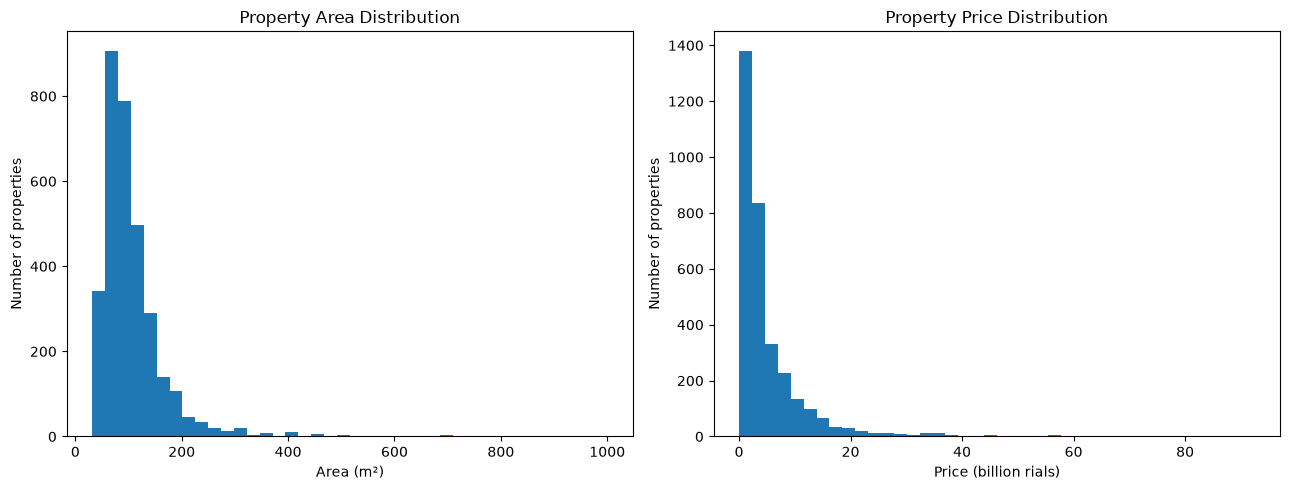

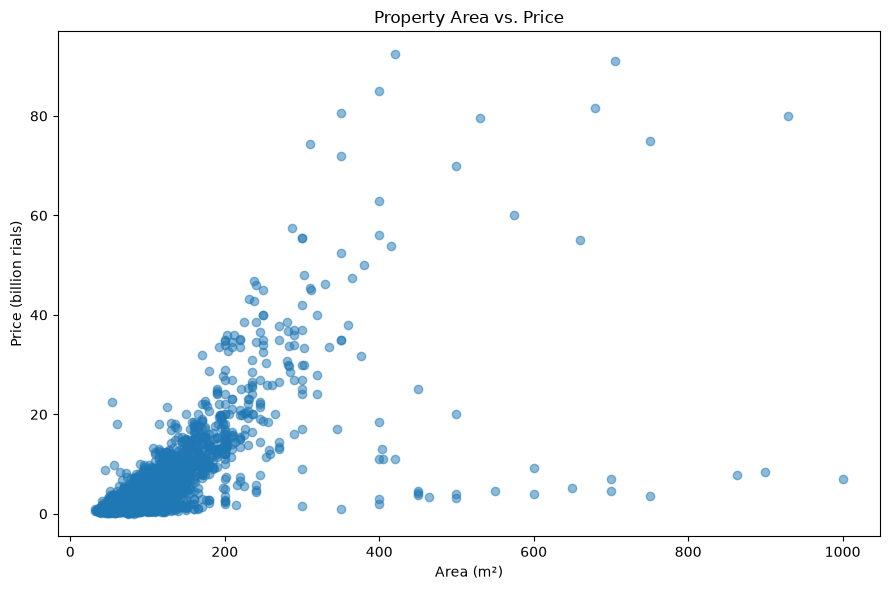

In [91]:

import matplotlib.pyplot as plt

figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(clean_df["Area"], bins=40)
axes[0].set_title("Property Area Distribution")
axes[0].set_xlabel("Area (m²)")
axes[0].set_ylabel("Number of properties")

axes[1].hist(clean_df["Price"] / 1e9, bins=40)
axes[1].set_title("Property Price Distribution")
axes[1].set_xlabel("Price (billion rials)")
axes[1].set_ylabel("Number of properties")

plt.tight_layout()
plt.savefig(
    figures_dir / "cleaned_area_price_distributions.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(9, 6))
plt.scatter(
    clean_df["Area"],
    clean_df["Price"] / 1e9,
    alpha=0.5
)
plt.title("Property Area vs. Price")
plt.xlabel("Area (m²)")
plt.ylabel("Price (billion rials)")
plt.tight_layout()
plt.savefig(
    figures_dir / "area_vs_price.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()
